In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/processed/features.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

model = pickle.load(open('../models/churn_model_v1.pkl', 'rb'))

# Add churn probability to dataframe
df['churn_prob'] = model.predict_proba(X)[:, 1]
df['churn_pred'] = model.predict(X)

print("Loaded! ✅")
print("Total customers:", len(df))

Loaded! ✅
Total customers: 7043


In [4]:
def assign_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_segment'] = df['churn_prob'].apply(assign_risk)

segment_counts = df['risk_segment'].value_counts()

print("=" * 40)
print("     RISK SEGMENT BREAKDOWN")
print("=" * 40)
for segment, count in segment_counts.items():
    pct = count / len(df) * 100
    print(f"  {segment:<15} {count:>5} customers ({pct:.1f}%)")

     RISK SEGMENT BREAKDOWN
  Low Risk         3956 customers (56.2%)
  Medium Risk      1659 customers (23.6%)
  High Risk        1428 customers (20.3%)


In [5]:
def churn_playbook(row):
    prob    = row['churn_prob']
    high_val = row['is_high_value']
    new_cust = row['is_new_customer']
    services = row['total_services']

    # Rule 1 — High value + high risk → personal support
    if high_val == 1 and prob >= 0.7:
        return 'Assign dedicated support agent'

    # Rule 2 — New customer + high risk → onboarding help
    elif new_cust == 1 and prob >= 0.6:
        return 'Send onboarding assistance email'

    # Rule 3 — Low services + high risk → upsell bundle
    elif services <= 2 and prob >= 0.6:
        return 'Offer service bundle discount'

    # Rule 4 — Medium risk → re-engagement email
    elif 0.4 <= prob < 0.7:
        return 'Send re-engagement email'

    # Rule 5 — High risk but none of above → offer discount
    elif prob >= 0.7:
        return 'Offer retention discount'

    # Rule 6 — Low risk → no action needed
    else:
        return 'No action needed'

df['recommended_action'] = df.apply(churn_playbook, axis=1)

print("Playbook applied! ✅")
print("\nAction Distribution:")
print(df['recommended_action'].value_counts().to_string())

Playbook applied! ✅

Action Distribution:
recommended_action
No action needed                    3956
Send re-engagement email            1114
Assign dedicated support agent      1051
Send onboarding assistance email     591
Offer service bundle discount        331


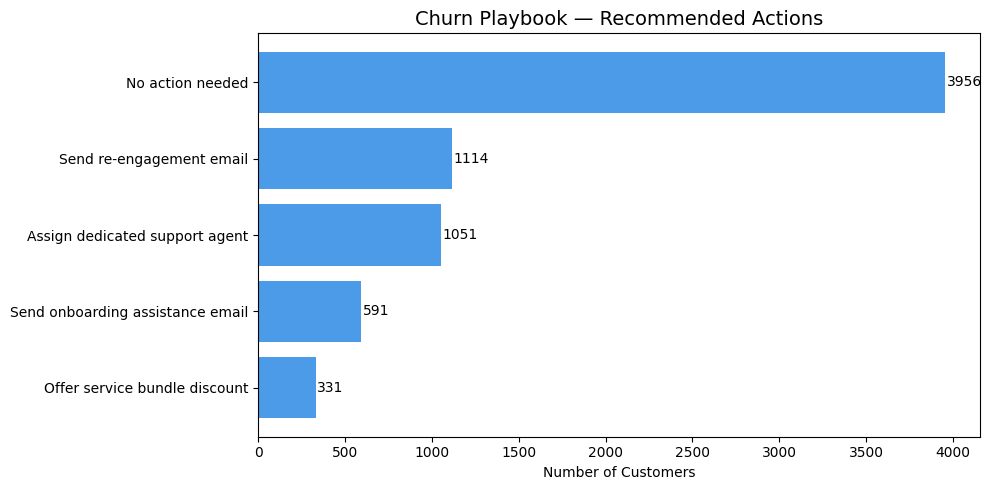

In [6]:
action_counts = df['recommended_action'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(action_counts.index, action_counts.values,
               color='#4C9BE8', edgecolor='none')

for bar, val in zip(bars, action_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title('Churn Playbook — Recommended Actions', fontsize=14)
ax.set_xlabel('Number of Customers')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/playbook_actions.png', dpi=150)
plt.show()

In [7]:
priority_actions = [
    'Assign dedicated support agent',
    'Send onboarding assistance email',
    'Offer service bundle discount'
]

priority_customers = df[df['recommended_action'].isin(priority_actions)]\
    .sort_values('churn_prob', ascending=False)\
    .head(20)

print("=" * 55)
print("     TOP 20 PRIORITY CUSTOMERS — ACT NOW")
print("=" * 55)
print(priority_customers[['churn_prob', 'risk_segment',
                           'is_high_value', 'is_new_customer',
                           'recommended_action']].to_string(index=False))

     TOP 20 PRIORITY CUSTOMERS — ACT NOW
 churn_prob risk_segment  is_high_value  is_new_customer             recommended_action
   0.970317    High Risk              1                1 Assign dedicated support agent
   0.968400    High Risk              1                1 Assign dedicated support agent
   0.966029    High Risk              1                1 Assign dedicated support agent
   0.963238    High Risk              1                1 Assign dedicated support agent
   0.963198    High Risk              1                1 Assign dedicated support agent
   0.963063    High Risk              1                1 Assign dedicated support agent
   0.962249    High Risk              1                1 Assign dedicated support agent
   0.962088    High Risk              1                1 Assign dedicated support agent
   0.960118    High Risk              1                1 Assign dedicated support agent
   0.959150    High Risk              1                1 Assign dedicated suppo

In [8]:
# Save full playbook
df[['churn_prob', 'risk_segment', 'recommended_action', 'Churn']]\
    .to_csv('../data/processed/churn_playbook.csv', index=False)

# Save only customers needing action
action_needed = df[df['recommended_action'] != 'No action needed']\
    .sort_values('churn_prob', ascending=False)

action_needed[['churn_prob', 'risk_segment', 'recommended_action']]\
    .to_csv('../data/processed/action_needed.csv', index=False)

print("=" * 45)
print("  PLAYBOOK SAVED ✅")
print("=" * 45)
print(f"\n  Total customers        : {len(df)}")
print(f"  Customers needing action: {len(action_needed)}")
print(f"  High risk customers     : {len(df[df['risk_segment'] == 'High Risk'])}")
print(f"\n  Files saved to data/processed/")

  PLAYBOOK SAVED ✅

  Total customers        : 7043
  Customers needing action: 3087
  High risk customers     : 1428

  Files saved to data/processed/


In [9]:
print("=" * 50)
print("     CHURN DEEP DIVE — PROJECT COMPLETE 🎯")
print("=" * 50)
print(f"""
  NOTEBOOKS COMPLETED:
  ✅ 01_eda.ipynb
  ✅ 02_feature_engineering.ipynb
  ✅ 03_model_training.ipynb
  ✅ 04_root_cause_analysis.ipynb
  ✅ 05_churn_playbook.ipynb

  MODEL PERFORMANCE:
  ✅ Mean AUC     : 0.844
  ✅ Std Dev      : 0.012

  OUTPUTS GENERATED:
  ✅ 7 charts saved in reports/
  ✅ churn_model_v1.pkl
  ✅ feature_importance.json
  ✅ root_causes.csv
  ✅ churn_playbook.csv
  ✅ action_needed.csv
""")
print("=" * 50)

     CHURN DEEP DIVE — PROJECT COMPLETE 🎯

  NOTEBOOKS COMPLETED:
  ✅ 01_eda.ipynb
  ✅ 02_feature_engineering.ipynb
  ✅ 03_model_training.ipynb
  ✅ 04_root_cause_analysis.ipynb
  ✅ 05_churn_playbook.ipynb

  MODEL PERFORMANCE:
  ✅ Mean AUC     : 0.844
  ✅ Std Dev      : 0.012

  OUTPUTS GENERATED:
  ✅ 7 charts saved in reports/
  ✅ churn_model_v1.pkl
  ✅ feature_importance.json
  ✅ root_causes.csv
  ✅ churn_playbook.csv
  ✅ action_needed.csv

